<a href="https://colab.research.google.com/github/TommasoToti/MLCC-2026-Lab/blob/main/Lab2_RLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Regularized Least Square
In this lab, we focus on RLS to address linear regression problems.

In this lab, we have to:
- **(Task 1)** implement RLS to solve linear regression problems
- **(Task 2)** observe performance of RLS changing the noise in the data and the regularization parameter
- **(Task 3)** implement K-Fold Cross-Validation algorithm for RLS


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

## Data generation
To generate linear regression data, we use the `linearRegrFunction` introduced in Lab0.

In [ ]:
from numpy.random import Generator


def _check_random_generator(rng: int | Generator | None) -> Generator:
    """Convert rng into a np.random.Generator instance."""
    if rng is None:
        print("⚠️  Warning: Set the `rng` parameter to a NumPy random generator\n"
              "   (e.g. `np.random.default_rng(42)`) or specify a fixed seed to ensure\n"
              "   your results are reproducible. Proceeding with a random seed for now.")
        return np.random.default_rng()
    if isinstance(rng, np.random.Generator):
        return rng
    if isinstance(rng, (int, np.integer)):
        return np.random.default_rng(rng)


def linearRegrFunction(n, D, low_D, high_D, W, sigma_noise, rng: int | Generator | None = None):
    rng = _check_random_generator(rng)

    X = np.zeros((n,D), dtype=np.float64)
    for j in range(D):
        X[:,j] = rng.uniform(low_D[j], high_D[j], size=n)

    gauss_noise = rng.normal(0, sigma_noise, size=(n,1))

    Y = np.dot(X, W) + gauss_noise

    return X, Y

### Example: Noiseless dataset


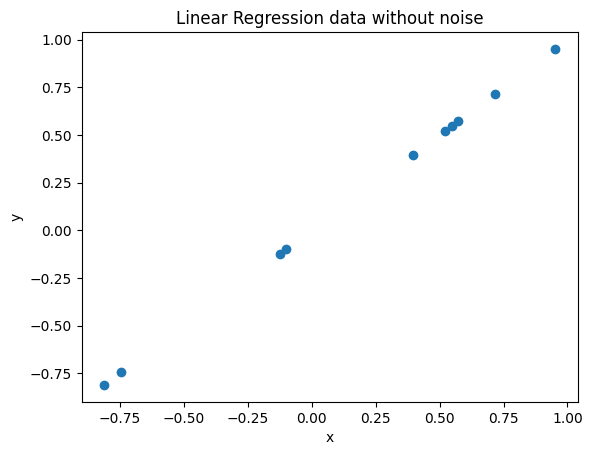

In [ ]:
n = 10
D = 1
low_D, high_D = [-1], [1]
w = np.array(1.0).reshape(1,1)
noise_std = 0.0
rng = 42

# Data generation
X, Y = linearRegrFunction(n, D, low_D, high_D, w, noise_std, rng)

# Plot of the data
_, ax = plt.subplots()
ax.set_title("Linear Regression data without noise")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(X, Y)

### Example: Noisy dataset

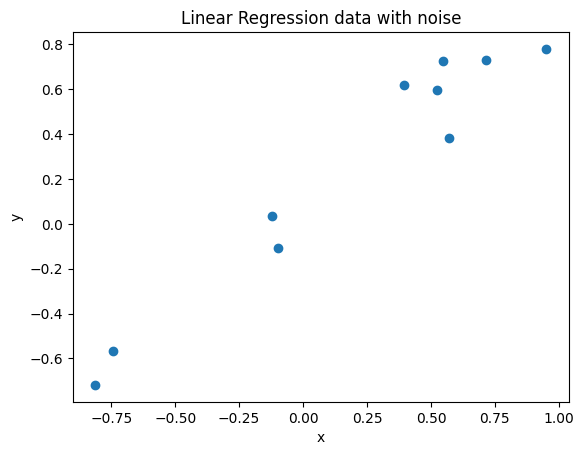

In [ ]:
n = 10
D = 1
low_D, high_D = [-1], [1]
w = np.array(1.0).reshape(1,1)
noise_std = 0.2
rng = 42

# Data generation
X, Y = linearRegrFunction(n, D, low_D, high_D, w, noise_std, rng)

# Plot of the data
_, ax = plt.subplots()
ax.set_title("Linear Regression data with noise")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(X, Y)

## Task 1: RLS regressor
We want to implement the `regularizedLSTrain` function which train RLS regression.

The signature of `regularizedLSTrain` is the following:

`w = regularizedLSTrain(Xtr, Ytr, lam)`

where:
- **Xtr** are the training inputs
- **Ytr** are the training outputs
- **lam** is the regularization parameter $\lambda$

To implement this function, you will need to use the following function from SciPy:

- [`scipy.linalg.solve`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve.html)

Consider

**$(X_{tr}^\intercal X_{tr} + \lambda n I)w = X_{tr}^\intercal Y_{tr}$**

Let $A = X_{tr}^\intercal X_{tr} + \lambda n I$ and $b = X_{tr}^\intercal Y_{tr}$, we can find $w$ with the following steps:
1. First build the left-hand side matrix `A`, and the right-hand side matrix `b`.
2. Solve the linear system `A @ w = b` directly with `scipy.linalg.solve`.
3. Since `A` is symmetric positive definite when `lam > 0`, you can pass `assume_a="pos"` to use the positive-definite solver.

In [ ]:
def regularizedLSTrain(Xtr, Ytr, lam):
   A = np.transpose(Xtr) @ Xtr + lam * Xtr.shape[0] * np.identity(Xtr.shape[1])
   b = np.transpose(Xtr) @ Ytr
   w = scipy.linalg.solve(A, b, assume_a="pos")
   return w


We need also to implement a function `regularizedLSTest` which given a test set `Xte` and the `w` obtained using `regularizedLSTrain`, it returns `Ypred` containing the predictions

In [ ]:
def regularizedLSTest(w, Xte):
    return Xte @ w

To evaluate the performance of RLS regressor, we need a function to estimate the error.

Given two vectors `Ytrue` (real outputs) and `Ypred` (predicted outputs), we can measure the error obtained when predicting `Ypred` instead of `Ytrue` with the MSE (Mean Square Error)

In [ ]:
def calcError(Ypred, Ytrue):
    return np.mean((Ypred-Ytrue)**2)

Now we can build an easy example to observe how our model works:
- Generate a training set with **ntrain** points and a test set with **ntest** points
- Train RLS with `regularizedLSTrain` function and test it with `regularizedLSTest` on test set
- Compute the training and test error

[--] Training error (MSE): 0.0095789	 Test error (MSE): 0.0110824


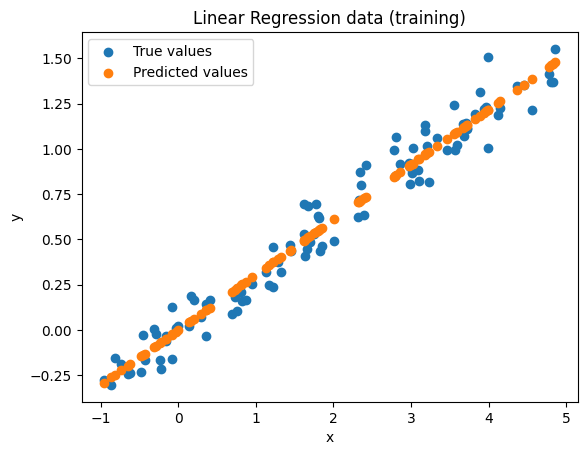

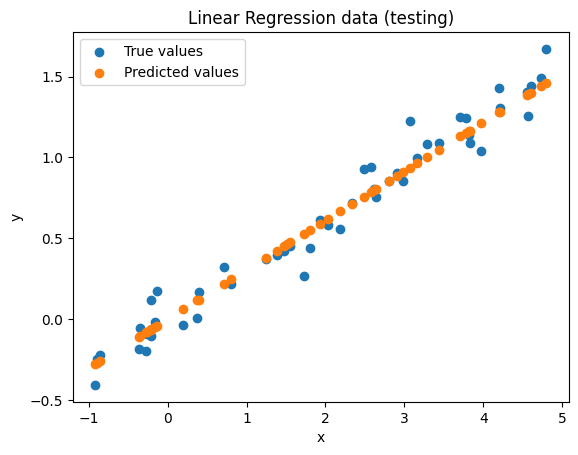

In [ ]:
n_train = 100
n_test = 50
D = 1
low_D = [-1] * D
high_D = [5] * D
rng_seed = 42
rng = _check_random_generator(rng_seed)
w_true = rng.standard_normal((D, 1))
noise_std = 0.1

lam = 1e-3

# Generate a training set with n_train points and a test set with n_test
Xtr, Ytr = linearRegrFunction(n_train, D, low_D, high_D, w_true, noise_std, rng)
Xte, Yte = linearRegrFunction(n_test, D, low_D, high_D, w_true, noise_std, rng)

# Train RLS
w_pred = regularizedLSTrain(Xtr, Ytr, lam)

# Compute predictions on training and test set
Ytr_pred = regularizedLSTest(w_pred, Xtr)
Yte_pred = regularizedLSTest(w_pred, Xte)

# Compute training and test error
train_err = calcError(Ytr_pred, Ytr)
test_err = calcError(Yte_pred, Yte)

print(f'[--] Training error (MSE): {train_err:.7f}\t Test error (MSE): {test_err:.7f}')

# Plot of the data (training)
_, ax = plt.subplots()
ax.set_title("Linear Regression data (training)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(Xtr, Ytr, label='True values')
ax.scatter(Xtr, Ytr_pred, label='Predicted values')
ax.legend()

# Plot of the data (testing)
_, ax = plt.subplots()
ax.set_title("Linear Regression data (testing)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(Xte, Yte, label='True values')
ax.scatter(Xte, Yte_pred, label='Predicted values')
ax.legend()

## Task 2: Changing $\lambda$
Now we can play with our model changing the noise level in the data and changing the $\lambda$ parameter.

Let's start by changing $\lambda$ and fixing the other parameters.

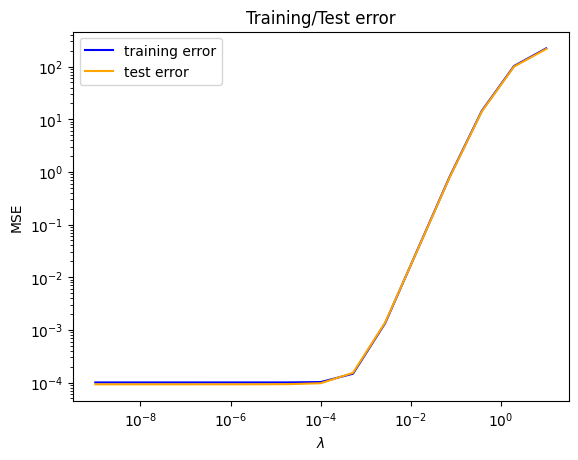

In [ ]:
n_train = 500
n_test = 100
D = 2
low_D = [-2] * D
high_D = [2] * D
rng_seed = 42
rng = _check_random_generator(rng_seed)
w_true = np.arange(D)[:, None] + 10
noise_std = 0.01

# Data generation
Xtr, Ytr = linearRegrFunction(n_train, D, low_D, high_D, w_true, noise_std, rng)
Xte, Yte = linearRegrFunction(n_test, D, low_D, high_D, w_true, noise_std, rng)

# Changing lambda

lam_list = np.logspace(-9, 1, 15)
tr_err = []
te_err = []

for lam in lam_list:
    # Train RLS
    w_pred = regularizedLSTrain(Xtr, Ytr, lam)
    # Compute predictions on training and test set
    Ytr_pred = regularizedLSTest(w_pred, Xtr)
    Yte_pred = regularizedLSTest(w_pred, Xte)

    # Compute training and test error and store them on tr_err and te_err
    tr_err.append(calcError(Ytr_pred, Ytr))
    te_err.append(calcError(Yte_pred, Yte))

# Plot training and test error
_, ax = plt.subplots()
ax.set_title("Training/Test error")
ax.loglog(lam_list, tr_err, '-', c="blue", label="training error")
ax.loglog(lam_list, te_err, '-', c="orange", label="test error")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("MSE")
ax.legend(loc="best");

### Comment

When $\lambda$ is smaller than $10^{-4}$ (low regularization), the model fits the training data well, and both training and test error are low and stable. This indicates the model is complex enough to capture the underlying patterns without being overly penalized.

If $\lambda$ becomes greater than $10^{-4}$ (high regularization), the model becomes overly simple and starts to underfit the data. This shows up as a significant increase in both training and test error.



## Task 3: K-Fold Cross Validation for RLS
Now, we want to implement the K-Fold Cross Validation for RLS.

In specific we want to implement the `KFoldCVRLS` function which, given a training set **Xtr** and **Ytr**, a number of folds **KF** and a set of values for $\lambda$ (**regpar_list**) and returns the $\lambda$ which minimize the average validation error **bestlam**, the mean validation error **val_mean**, the validation error variance **val_var**, the mean training error **tr_mean** and the training error variance **tr_var**.

`bestlam, val_mean, val_var, tr_mean, tr_var = KFoldCVRLS(Xtr, Ytr, KF, regpar_list)`

**Hint:** this function is very similar to K-Fold Cross-Validation algorithm for KNN (Lab1)

In [ ]:
def KFoldCVRLS(Xtr, Ytr, KF, regpar_list, rng: int | Generator | None = None):
    assert KF > 1, "A number of folds (KF) should be > 1"

    rng = _check_random_generator(rng)
    n_tot = Xtr.shape[0]
    n_val = n_tot // KF

    # Ensures that regpar_list is a numpy array
    regpar_list = np.asarray(regpar_list)
    num_regpar = regpar_list.size

    # We want to compute 1 error for each `k` and each fold
    tr_errors = np.zeros((num_regpar, KF), dtype=np.float64)
    val_errors = np.zeros((num_regpar, KF), dtype=np.float64)

    # 1) One permutation, once
    rand_idx = rng.permutation(n_tot)
    # 2) Split once into K disjoint folds
    split_idx = np.array_split(rand_idx, KF)
    # 3) Outer loop over folds; inner over hyperparams
    for fold in range(KF):
        val_mask = np.zeros(n_tot, dtype=bool)
        val_mask[split_idx[fold]] = True
        train_mask = ~val_mask

        for idx, regpar in enumerate(regpar_list):
            # Use the boolean mask to split X, Y in training and validation part

            X = Xtr[train_mask] # training input
            Y = Ytr[train_mask] # training output
            Xval = Xtr[val_mask] # validation input
            Yval = Ytr[val_mask] # validation output

            # Train a RLS model for a single fold, and the given value of `regpar`
            w_pred = regularizedLSTrain(X, Y, regpar)

            # Compute the training error of the RLS regression for the given value of `regpar`
            Y_pred = regularizedLSTest(w_pred, X)
            tr_errors[idx, fold] = calcError(Y_pred, Y)

            # Compute the validation error of the RLS regression for the given value of `regpar`
            Yval_pred = regularizedLSTest(w_pred, Xval)
            val_errors[idx, fold] = calcError(Yval_pred, Yval)

    # Calculate error statistics along the repetitions
    tr_mean = np.mean(tr_errors, axis=1)
    tr_var = np.var(tr_errors, axis=1)
    val_mean = np.mean(val_errors, axis=1)
    val_var = np.var(val_errors, axis=1)

    bestlam_idx = np.argmin(val_mean)
    bestlam = regpar_list[bestlam_idx]

    return bestlam, val_mean, val_var, tr_mean, tr_var

Use `KFoldCVRLS` to find the best regularization parameter

[--] Best lambda found: 0.0026561


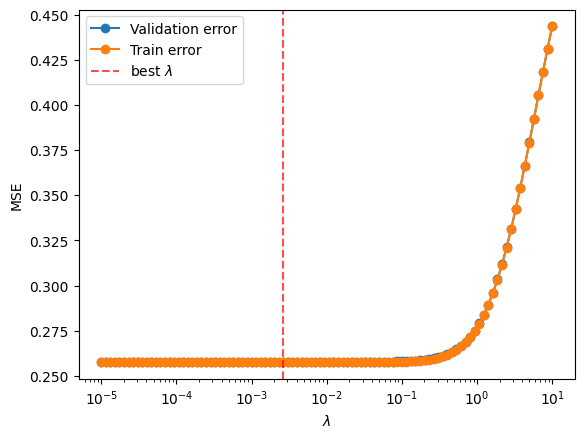

In [ ]:
n = 1000
D = 1
sigma_noise = 0.5
rng_seed = 42
rng = _check_random_generator(rng_seed)
w_true = rng.standard_normal((D, 1))
reg_pars = np.logspace(-5, 1, 100)
KF = 5

low_D = [-3] * D
high_D = [3] * D

# Generate training set
Xtr, Ytr = linearRegrFunction(n, D, low_D, high_D, w_true, sigma_noise, rng)

# Compute best lambda
bestlam, Vm, Vs, Tm, Ts = KFoldCVRLS(Xtr, Ytr, KF, reg_pars, rng)
print(f'[--] Best lambda found: {bestlam:.7f}')

# Plot training and validation error
_, ax = plt.subplots()
ax.plot(reg_pars, Vm, '-o', label="Validation error")
ax.plot(reg_pars, Tm, '-o', label="Train error")
ax.axvline(bestlam, linestyle="--", c="red", alpha=0.7, label=r"best $\lambda$")
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("MSE")
ax.legend(loc="best");

Plot the regression curve using the best $\lambda$ (found with `KFoldCVRLS`) and using the worst $\lambda$

[--] Best lambda found: 0.0026561
[--] Worst lambda found: 10.0000000


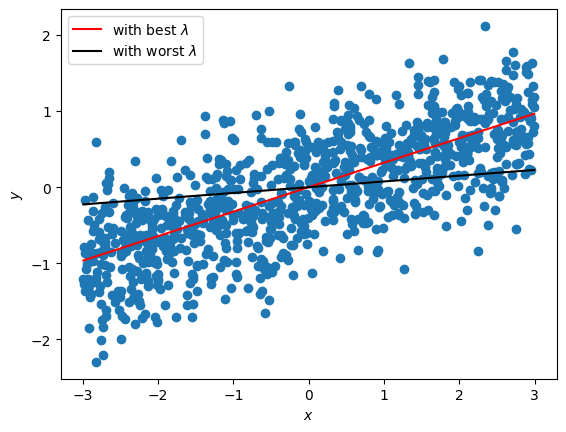

In [ ]:
# Best lambda
print(f'[--] Best lambda found: {bestlam:.7f}')
w_best = regularizedLSTrain(Xtr, Ytr, bestlam)
Ypred_best = regularizedLSTest(w_best, Xtr)

# Worst lambda
worstlam = reg_pars[-1]
print(f'[--] Worst lambda found: {worstlam:.7f}')
w_worst = regularizedLSTrain(Xtr, Ytr, worstlam)
Ypred_worst =  regularizedLSTest(w_worst, Xtr)

_, ax = plt.subplots()
ax.scatter(Xtr, Ytr)

# Use Xtr for plotting the regression lines, as Ypred_best/worst were computed using Xtr
# Sort Xtr to draw a continuous line
sort_idx = np.argsort(Xtr.squeeze())

ax.plot(Xtr[sort_idx], Ypred_best[sort_idx],  c="red", label=r"with best $\lambda$")
ax.plot(Xtr[sort_idx], Ypred_worst[sort_idx],c="black", label=r"with worst $\lambda$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend(loc="best");

Use the best $\lambda$ found to train the model on the full training set and compute the test error on the following test set.   

[--] Best lambda found: 0.0026561
[--] Test error: 0.2787047


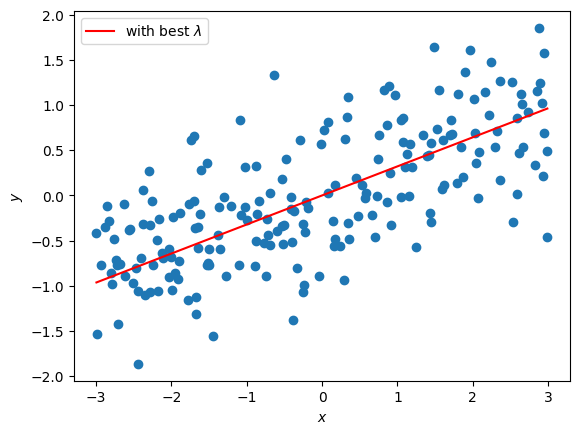

In [ ]:
Xte, Yte = linearRegrFunction(200, D, low_D, high_D, w_true, sigma_noise, rng)
print(f'[--] Best lambda found: {bestlam:.7f}')


w_best = regularizedLSTrain(Xtr, Ytr, bestlam)
Ypred_best = regularizedLSTest(w_best, Xte)
test_err = calcError(Ypred_best, Yte)
print(f'[--] Test error: {test_err:.7f}')

# Plots

_, ax = plt.subplots()
ax.scatter(Xte, Yte)
sort_idx = np.argsort(Xte.squeeze())

ax.plot(Xte[sort_idx], Ypred_best[sort_idx],  c="red", label=r"with best $\lambda$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend(loc="best");

### Repeat the procedure on a different dataset

Create new training **and** test datasets, sampled in a non-symmetric range (for example you can set the `low_D` and `high_D` parameters of the `linearRegrFunction` function to 2 and 5).

Then repeat the K-fold CV procedure, and check whether the best regularization parameter changes!

[--] Best lambda found: 0.0040370


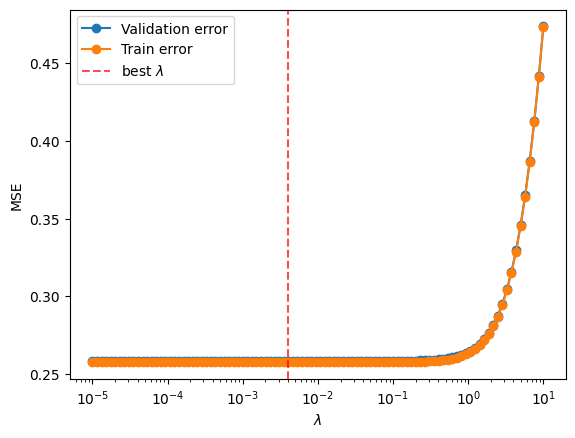

In [ ]:
n = 1000
D = 1
sigma_noise = 0.5
rng_seed = 42
rng = _check_random_generator(rng_seed)
w_true = rng.standard_normal((D, 1))
reg_pars = np.logspace(-5, 1, 100)
KF = 5

low_D = [2] * D
high_D = [5] * D

# Generate training set
Xtr, Ytr = linearRegrFunction(n, D, low_D, high_D, w_true, sigma_noise, rng)

# Compute best lambda
bestlam, Vm, Vs, Tm, Ts = KFoldCVRLS(Xtr, Ytr, KF, reg_pars, rng)
print(f'[--] Best lambda found: {bestlam:.7f}')

# Plot training and validation error
_, ax = plt.subplots()
ax.plot(reg_pars, Vm, '-o', label="Validation error")
ax.plot(reg_pars, Tm, '-o', label="Train error")
ax.axvline(bestlam, linestyle="--", c="red", alpha=0.7, label=r"best $\lambda$")
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("MSE")
ax.legend(loc="best");